In [1]:

import numpy as np
import matplotlib.pyplot as plt
import helpers as hp
from pathlib import Path
from config import PathConfigs
import os
import pandas as pd
import plotly.graph_objects as go

from scipy.stats import entropy
from IPython.display import display, HTML
display(HTML('<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'))



In [4]:

save_plots = True

#dirname = "qn100/vdis2_b_strdis"
#dirname = Path(PathConfigs.DATA/dirname)
#ave_dir = Path(PathConfigs.DATA/dirname/"Plots")

#os.makedirs(save_dir, exist_ok=True)

#Data/Old/Barrier5/Tdis_nb
#dirname = Path(PathConfigs.DATA/"mu_fix"/"vdis2_nb_strdis")
#dirname = Path(PathConfigs.DATA/"spectra_fix"/"Tdis_nb")
dirname = Path(PathConfigs.DATA/"dis_Testn")
plot_dir = Path(dirname, "Plots")
os.makedirs(plot_dir, exist_ok=True)



In [8]:

barrier_right_conductance_right_arr = hp.np_load_wrapped("barrier_right_conductance_right_arr", dirname)
barrier_right_conductance_left_arr = hp.np_load_wrapped("barrier_right_conductance_left_arr", dirname)
dIdVs_left_arr = hp.np_load_wrapped("dIdVs_left_arr", dirname)
dIdVs_right_arr = hp.np_load_wrapped("dIdVs_right_arr", dirname)
energies = hp.np_load_wrapped("energies", dirname)
pdi_arr = hp.np_load_wrapped("pdi_data", dirname)
Conductance_matrix = hp.np_load_wrapped("Conductance_matrix_zero_energy", dirname)
gamma_sq_arr = hp.np_load_wrapped("gamma_sq_arr", dirname)
mp_arr = hp.np_load_wrapped("mp_arr", dirname)
rG_corr = hp.np_load_wrapped("rG_corr", dirname)
params_list = np.load(Path(dirname, 'params_list.npy'))
spectrum_arr = hp.np_load_wrapped("spectrum_arr", dirname)
Vdisx = hp.np_load_wrapped("Vdisx", dirname)
barrier_arr = hp.np_load_wrapped("barrier_arr", dirname)


#ldos = hp.np_load_wrapped("LDOS", dirname)

#return [mu_pm * V_c, vz_raw, pdi_val]
#new_pdi_dat = np.asarray([[pdr[0]/V_c, pdr[1]*V_c, pdr[2]] for pdr in pdi_arr])


barrier_right_conductance_left_arr.shape

(14625, 7, 10)

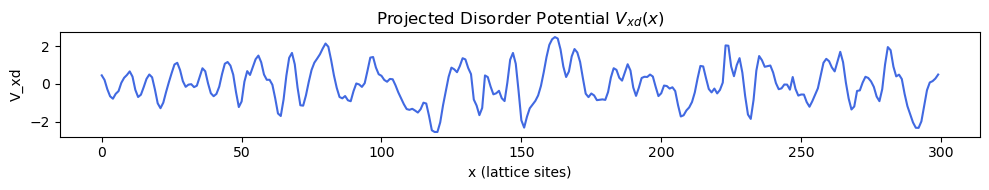

ΔVd = -0.0000
sqrt[<Vxd²>] = 1.0000


In [9]:
Nx = len(Vdisx)
plt.figure(figsize=(10, 2))
plt.plot(np.arange(Nx), Vdisx, color='royalblue')
plt.xlabel("x (lattice sites)")
plt.ylabel("V_xd")
plt.title("Projected Disorder Potential $V_{xd}(x)$")
plt.gca().set_aspect('auto')
plt.tight_layout()
plt.show()

# mean and variance
DeltaVd = np.mean(Vdisx)
VarVd = np.mean(Vdisx**2)
print(f"ΔVd = {DeltaVd:.4f}")
print(f"sqrt[<Vxd²>] = {np.sqrt(VarVd):.4f}")

In [10]:
def filter_pdi(pdis, thresh = 0.8):
    for i in range(len(pdis)):
        pdi = pdis[i]
        if pdi > 1.0:
            pdis[i] = 1.00
        elif pdi < 0.0:
            pdis[i] = 0
        
        if thresh:
            if pdi > thresh:
                pdis[i] =  1
            else:
                pdis[i] =  0
                
                
            
    return pdis
    

In [11]:
import numpy as np
import plotly.graph_objects as go

# Assuming pdi_arr and filter_pdi are already defined in your environment
mu = pdi_arr[:, 0]    # y-axis in the plot
V_z = pdi_arr[:, 1]   # x-axis in the plot
I = filter_pdi(pdi_arr[:, 2])  # z-axis (color)
#I = pdi_arr[:, 2]  # z-axis (color)

# Create the interactive Plotly heatmap/contour
fig = go.Figure(data=go.Contour(
    x=V_z,
    y=mu,
    z=I,
    colorscale='tempo_r',  # Matches Matplotlib's 'viridis'
    ncontours=100,         # Matches the levels=100 argument
    line_width=0,  
    showscale=False,
    contours=dict(
        coloring='heatmap',
        showlines=False
    ),
    colorbar=dict(
        title='Intensity (I)'
    )
))

# Label axes and title
# Plotly naturally renders LaTeX enclosed in $ symbols
fig.update_layout(
    title='Winding Number',
    xaxis_title=r'$V_z$ meV',
    yaxis_title=r'$\mu$ meV',
    xaxis_range=[0.0, 1.2],  # <-- SET YOUR X-AXIS LIMITS HERE
    yaxis_range=[0, 4.5],
    width=400,
    height=700
)

fig.show()

fig.write_image(Path(plot_dir, 'Winding_Number.png'))


In [ ]:

def invariant_metric(f1,f2):

    norm_f1 = (f1/np.max(f1)) 
    norm_f2 = (f2/np.max(f2))

    normf1mean = norm_f1[-1]
    normf2mean = norm_f2[-1]
    
    N = norm_f1.size
    
    if normf1mean > normf2mean:
        fmax = norm_f1
        fmin = norm_f2
    else:
        fmax = norm_f2
        fmin = norm_f1


    return (np.sum(1 - fmax)/np.sum(1-fmin)) 


def get_com(x,y):
    num = np.sum(x * y)
    denom = np.sum(y)
    return num/denom



In [ ]:
symm_KL = lambda p, q: 0.5*(entropy(p,q) + entropy(q,p))



brcl = barrier_right_conductance_left_arr
brcr = barrier_right_conductance_right_arr

#corrs = np.asarray([symm_KL(barrier_left_conductance_left_arr[i,:], barrier_left_conductance_right_arr[i,:]) for i in range(barrier_left_conductance_right_arr.shape[0])])
#corrs = corrs - corrs.min()
#corrs = corrs/corrs.max()
getmax_right = lambda i: (np.where(brcr[i,:] == np.max(brcr[i,:])))[0][0]
getmax_left = lambda i: (np.where(brcl[i,:] == np.max(brcl[i,:])))[0][0]


coms_right = np.asarray([get_com(barrier_arr, brcl[i,:]) for i in range(barrier_right_conductance_right_arr.shape[0])])
coms_left = np.asarray([get_com(barrier_arr, brcr[i,:]) for i in range(barrier_right_conductance_right_arr.shape[0])])

corrs = np.asarray([hp.calc_invariant_metric(brcl[i,:], brcr[i,:]) for i in range(barrier_right_conductance_right_arr.shape[0])])
diffs = np.asarray([brcl[i,:][-1] - brcr[i,:][-1] for i in range(barrier_right_conductance_right_arr.shape[0])])
normdiffs = np.asarray([brcl[i,:][-1]/brcl[i,:][0] - brcr[i,:][-1]/brcr[i,:][0] for i in range(barrier_right_conductance_right_arr.shape[0])])

lastcond_left = np.asarray([brcl[i,:][-1] for i in range(barrier_right_conductance_right_arr.shape[0])])
lastcond_right = np.asarray([brcr[i,:][-1] for i in range(barrier_right_conductance_right_arr.shape[0])])

norm_lastcond_left = np.asarray([brcl[i,-1]/brcl[i,0] for i in range(barrier_right_conductance_right_arr.shape[0])])
norm_lastcond_right = np.asarray([brcr[i,-1]/brcr[i,0] for i in range(barrier_right_conductance_right_arr.shape[0])])

max_peaks_right = np.asarray([getmax_right(i) for i in range(barrier_right_conductance_right_arr.shape[0])]) 
max_peaks_right = barrier_arr[max_peaks_right] - barrier_arr[0]
max_peaks_left = np.asarray([getmax_left(i) for i in range(barrier_right_conductance_right_arr.shape[0])]) 
max_peaks_left = barrier_arr[max_peaks_left] - barrier_arr[0]


thresh = 0.8
corrs = np.asarray([1.0 if corr > 1 else corr for corr in corrs])
corrs = np.asarray([0.0 if corr < 0.0 else corr for corr in corrs])
###
corrs = np.asarray([0.0 if corr < thresh else corr for corr in corrs])
corrs = np.asarray([1.0 if corr > thresh else corr for corr in corrs])


In [ ]:
maxd = 1000
filter_peaks = np.asarray([maxd if val>maxd else val for val in max_peaks_left])
mu = params_list[:, 1]   # y-axis in the plot
V_z = params_list[:, 2]  # x-axis in the plot
zplot = filter_peaks            # z-axis (color)

# Create the interactive Plotly heatmap/contour
fig = go.Figure(data=go.Contour(
    x=V_z,
    y=mu,
    z=zplot,
    colorscale='thermal',    # Matches Matplotlib's 'magma'
    ncontours=100,         # Smooth continuous gradient
    line_width=0,          # Removes contour lines
    contours=dict(
        coloring='heatmap',
        showlines=False
    ),
    colorbar=dict(
        title='Difference'
    )
))
#fig.update_xaxes(title=dict(text=r'\mu'))

# Label axes and title
fig.update_layout(
    title='barrier diff from Symmetric to peak (L)',
    xaxis_range=[0.0, 1.2],  # <-- SET YOUR X-AXIS LIMITS HERE
    yaxis_range=[0, 4.5],
    width=400,
    height=700,
    xaxis_title=r'$V_z$',
    yaxis_title=r'$\mu$',
)
